


# **Fine-tuning to follow instructions**






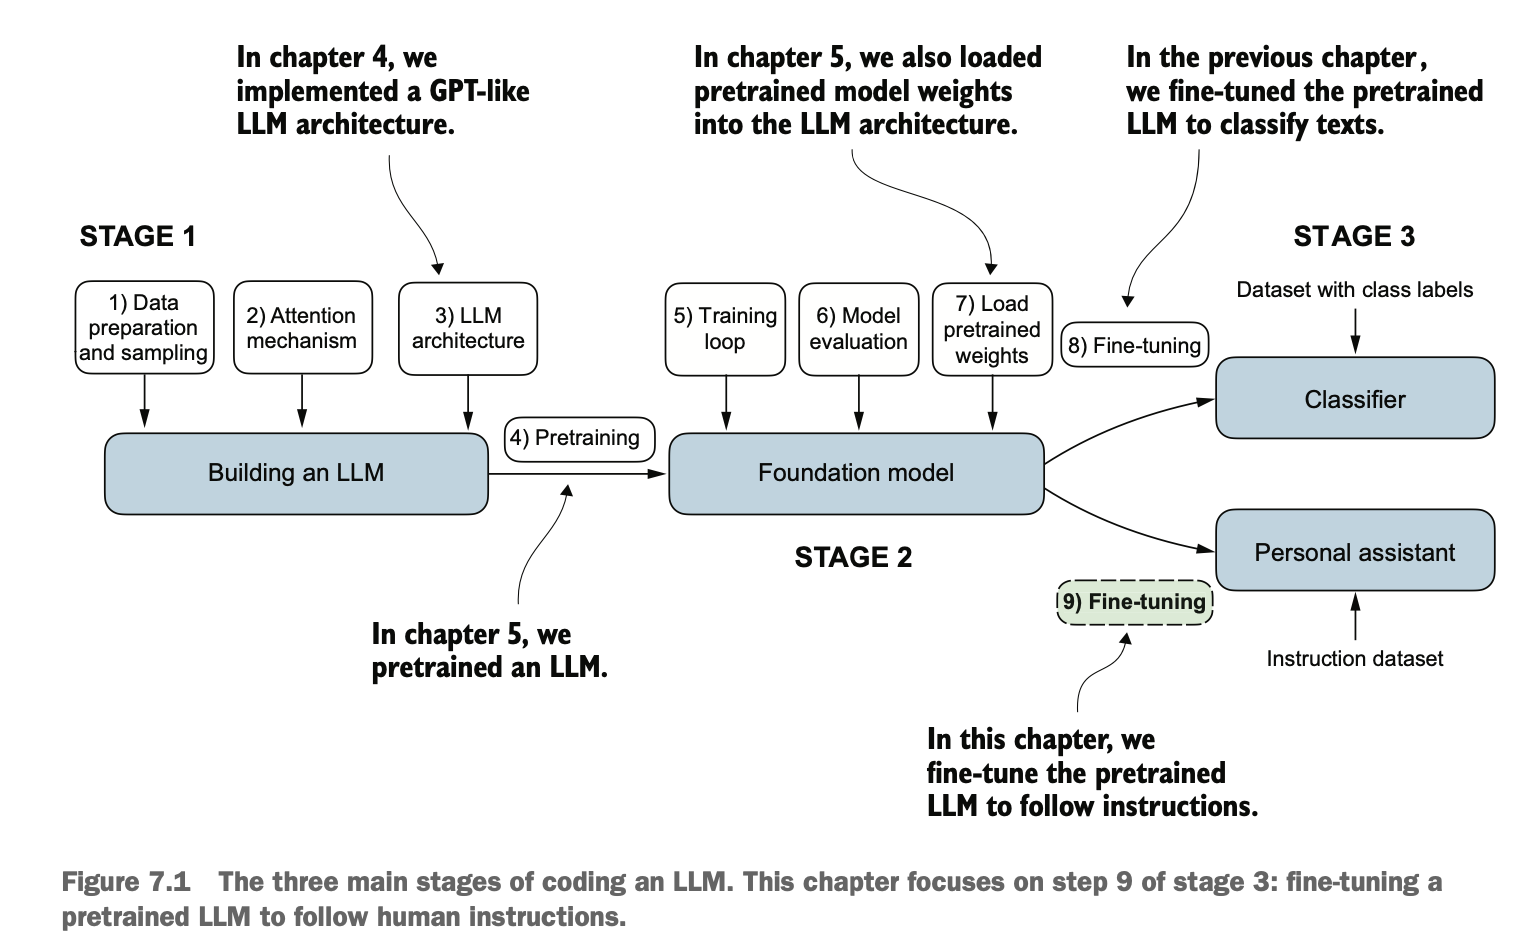

**Introduction to instruction fine_tuning**

A basic AI learns by predicting the next word in text. But this makes it only good at completing text — not following commands like "Fix my grammar".
Instruction fine-tuning is extra training that teaches the AI to actually follow instructions and give useful answers.English Summary
A pretrained LLM learns to complete text word by word, but it struggles to follow specific instructions like fixing grammar or changing sentence structure.
Instruction fine-tuning is extra training that teaches the LLM to properly understand and follow instructions to give useful responses.

The process has 3 main stages:

Prepare the dataset — collect instructions with correct responses

Fine-tune the model — train it on that dataset

Result — LLM can now follow instructions
properly


**Roman Urdu Summary**

Ek pretrained LLM sirf text complete karna jaanta hai — yani agle words predict karta hai. Lekin yeh specific instructions follow nahi kar sakta, jaise:

"Grammar theek karo"
"Passive voice mein badlo"

Instruction fine-tuning ek extra training hai jisme LLM ko sikhaya jata hai ke instructions ko samjhe aur sahi jawab de.

3 main steps hain:

Dataset tayyar karo — instructions aur sahi jawab ikattha karo
Model train karo — us data pe
Natija — LLM ab instructions achhi tarah follow kar sakta hai ✅

The key steps are:

Prepare a good dataset of instructions + correct responses

Train the AI on that dataset

Now it can properly respond to commands!



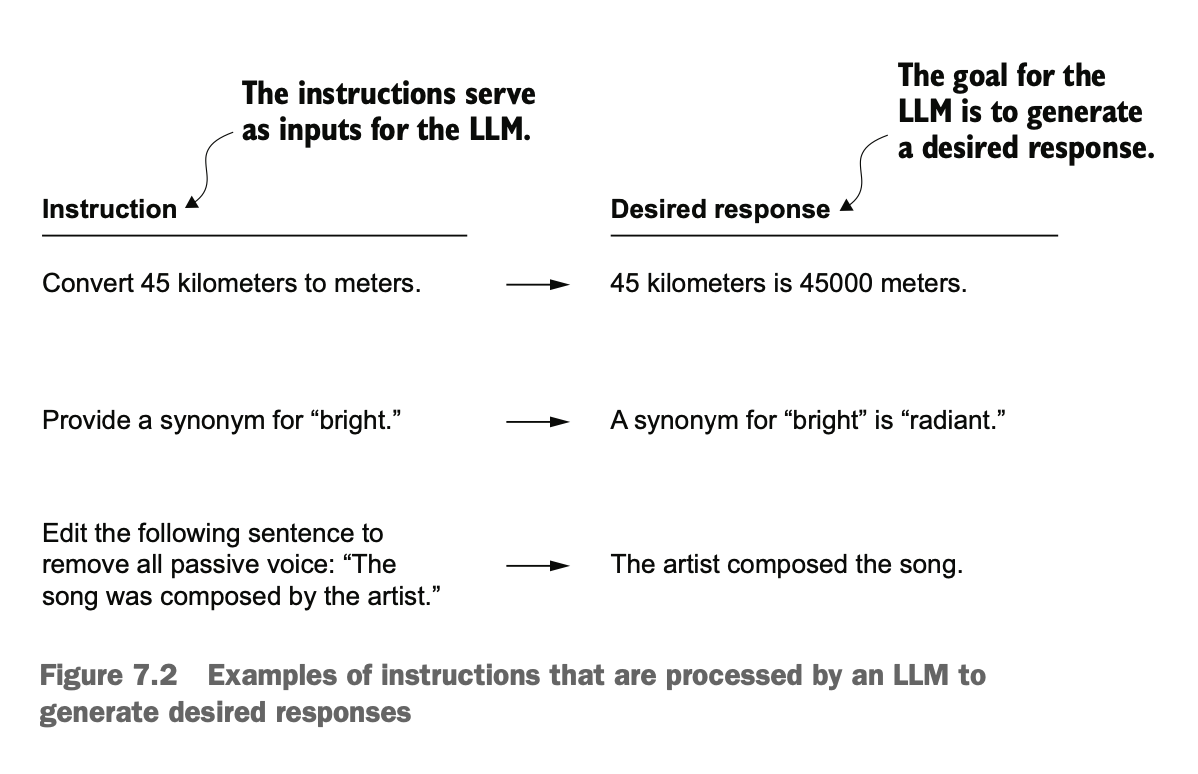


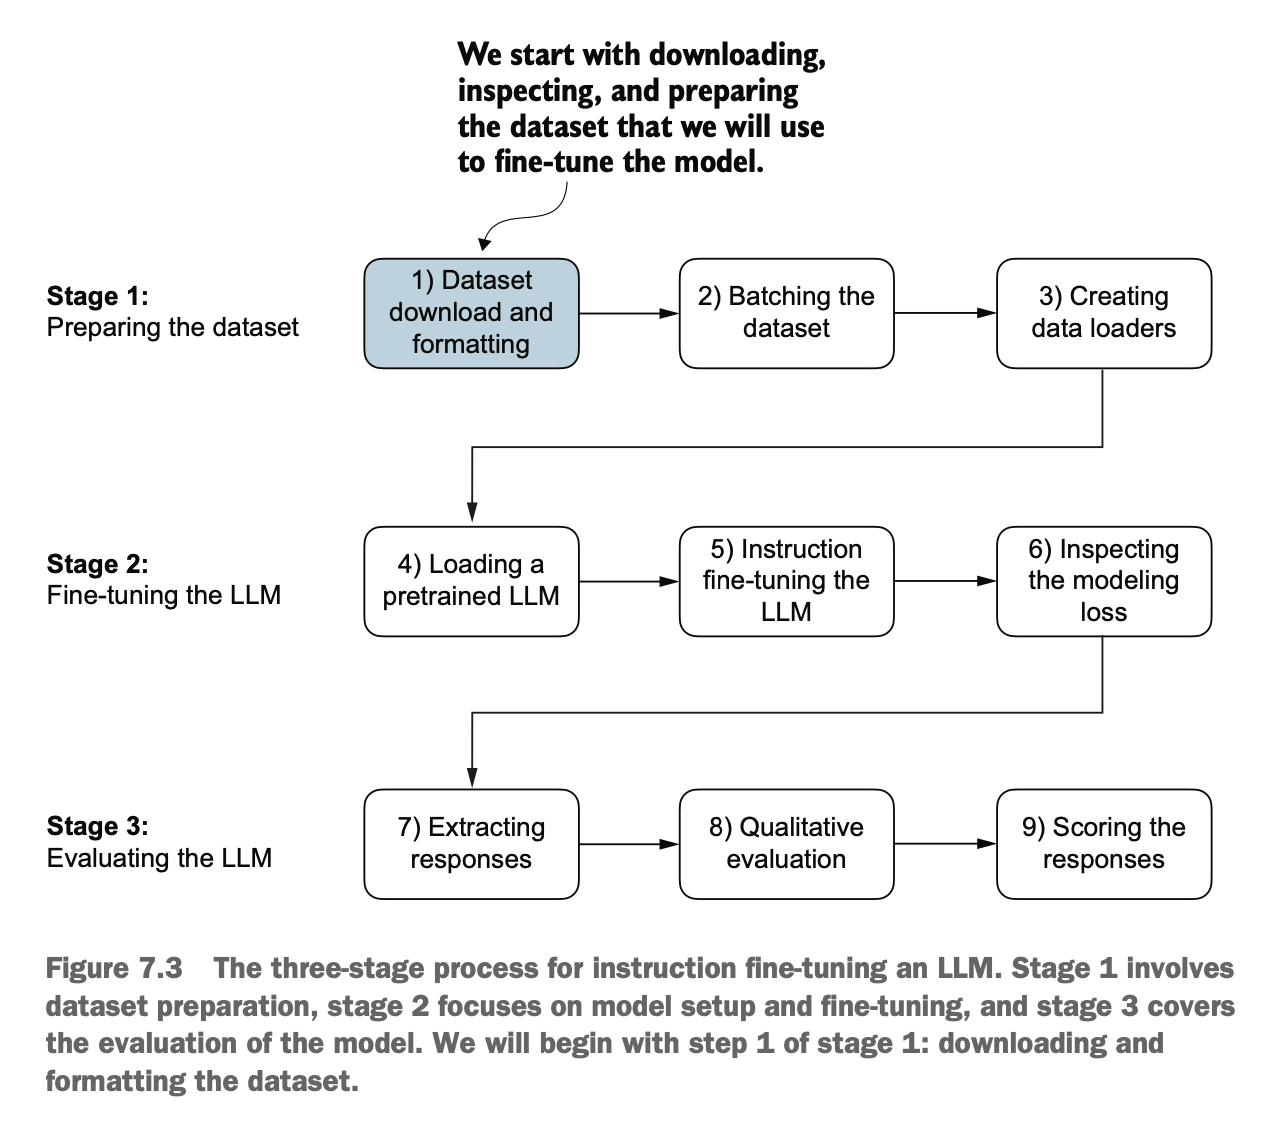

# **data download and load**

In [1]:
# data download and load

import json
import os
import urllib



**Preparing a dataset for supervised instruction fine-tuning**

To train an LLM to follow instructions, we first need a dataset of instruction-response pairs.
Key points:

The dataset has 1,100 instruction-response pairs

It is a small file (204 KB) in JSON format

JSON is like a Python dictionary — easy for both humans and machines to read

The dataset is downloaded and formatted before fine-tuning begins

JSON was chosen because it is simple, readable, and widely used for storing structured data.

In [2]:
def download_and_load_file(file_path , url): #-> we ctrate the function and pass 2 parameters in the function
  if not os.path.exists(file_path):# -> condition if file is not exist in the computer
    with urllib.request.urlopen(url) as response:# -> we will send the response throug urllib and through  urlopen we will open the link
      text_data = response.read().decode("utf-8")# -> that response save in the variable
    with open(file_path , "w" ) as file:# -> we create the file where we will store the respnse
      file.write(text_data)# -> here we will write the response
  else:
    with open(file_path , "r",encoding = "utf-8" ) as file:
      text_data = file.read()


    with open (file_path , "r" , encoding = "utf-8") as file:

       text_data=json.load(file)
  return text_data

file_path = "instruction_dataset.json"
url = ("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
"/main/ch07/01_main-chapter-code/instruction-data.json" )

data = download_and_load_file(file_path , url)

print("number of entries -> : ",len(data))



number of entries -> :  203524


In [3]:
print("examples entry",data[50])

examples entry w


In [4]:
print("another entries -> ",data[999])

another entries ->   


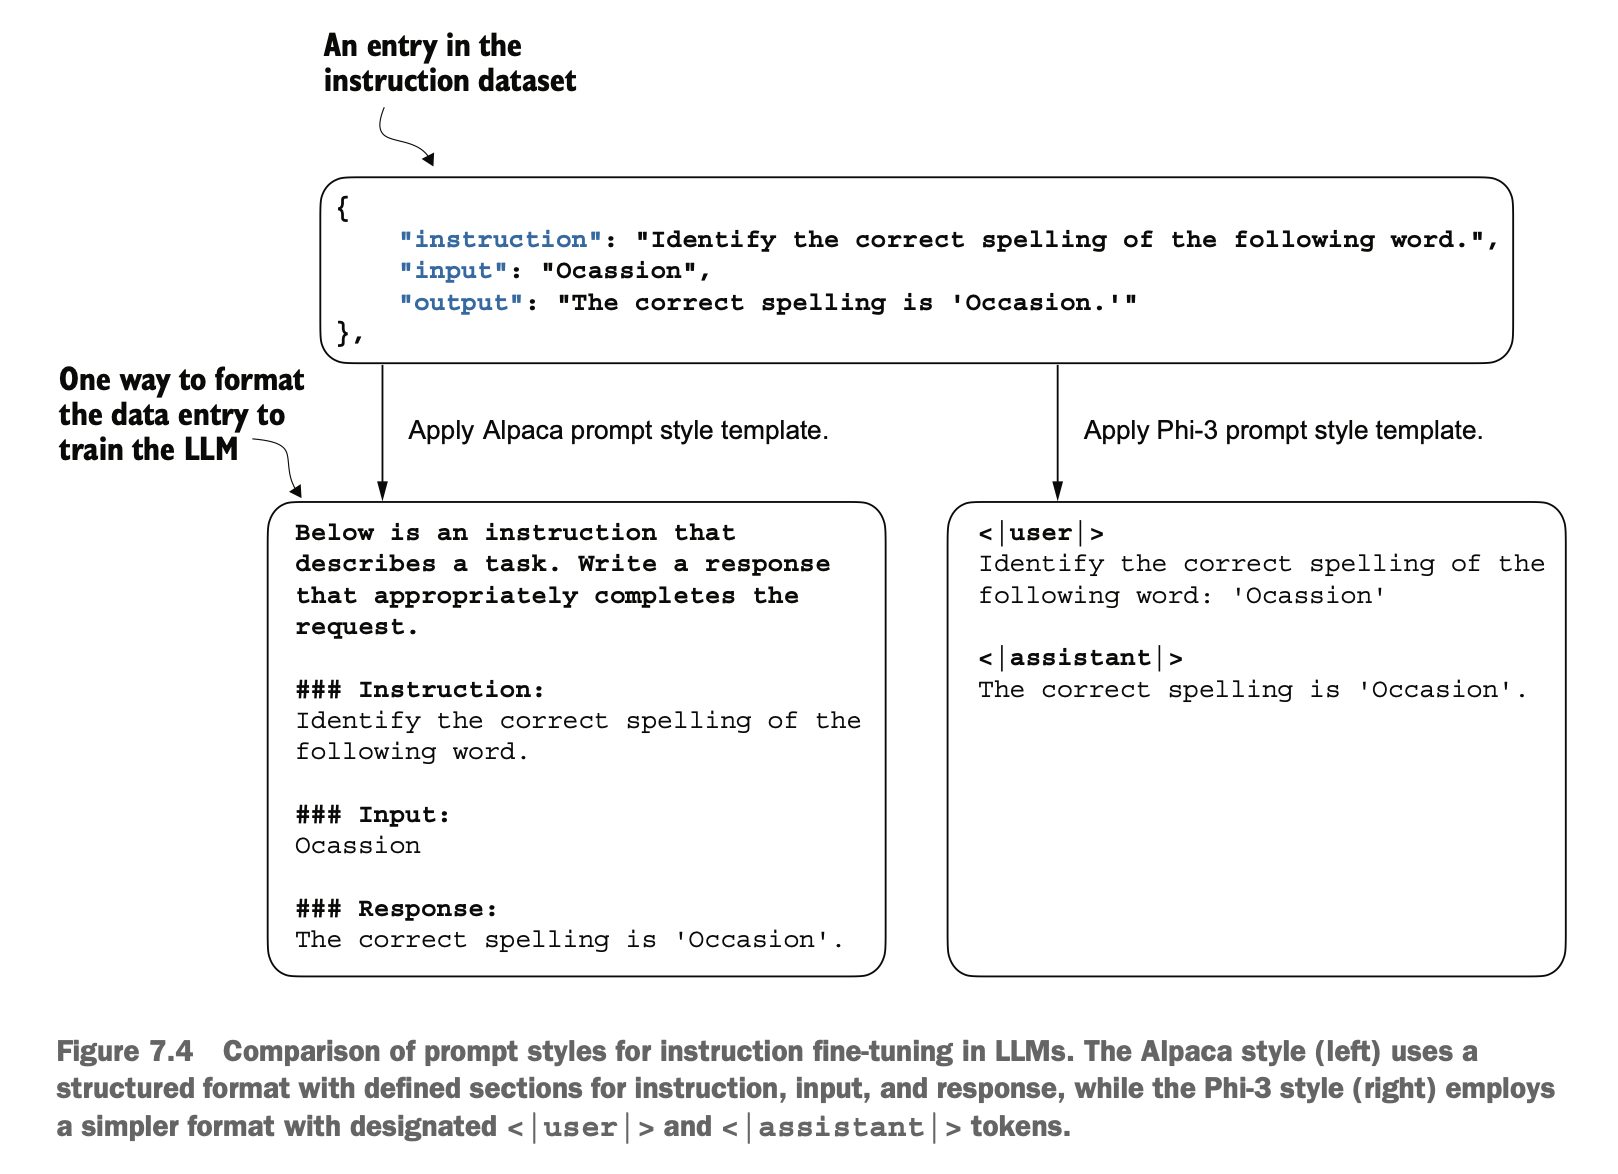

example formats, often referred to as prompt styles, used in the training of notable LLMs such as Alpaca and Phi-3.

Alpaca was one of the early LLMs to publicly detail its instruction fine-tuning pro- cess. Phi-3, developed by Microsoft, is included to demonstrate the diversity in prompt styles. The rest of this chapter uses the Alpaca prompt style since it is one of the most popular ones, largely because it helped define the original approach to fine-tuning.






**Let’s define a format_input function that we can use to convert the entries in the data list into the Alpaca-style input format.**

In [5]:
#Implementing the prompt formatting function
def formate_input(entry):
  instruction_input = (

                      f"Below is an instruction that describes a task. "
   f"Write a response that appropriately completes the request."
                       f"\n\n### instruction :{entry["instruction"]}"
  )
  input = (

           f"\n\n### input : {entry ["input"]}"

           if entry["input"]
           else ""

  )
  return instruction_input + input



In [6]:
input = formate_input(data[50])
desire_output = f"\n\n### output ,{data[50]["output"]}"
print(input)
print(desire_output)






TypeError: string indices must be integers, not 'str'

In [7]:
input = formate_input(data[999])
desire_output = f"\n\n### output ,{data[999]["output"]}"
print(input)
print(desire_output)


TypeError: string indices must be integers, not 'str'

In [8]:
# Partitioning the dataset


train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion
train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))


Training set length: 172995
Validation set length: 10177
Test set length: 20352


# **Batching the dataset**





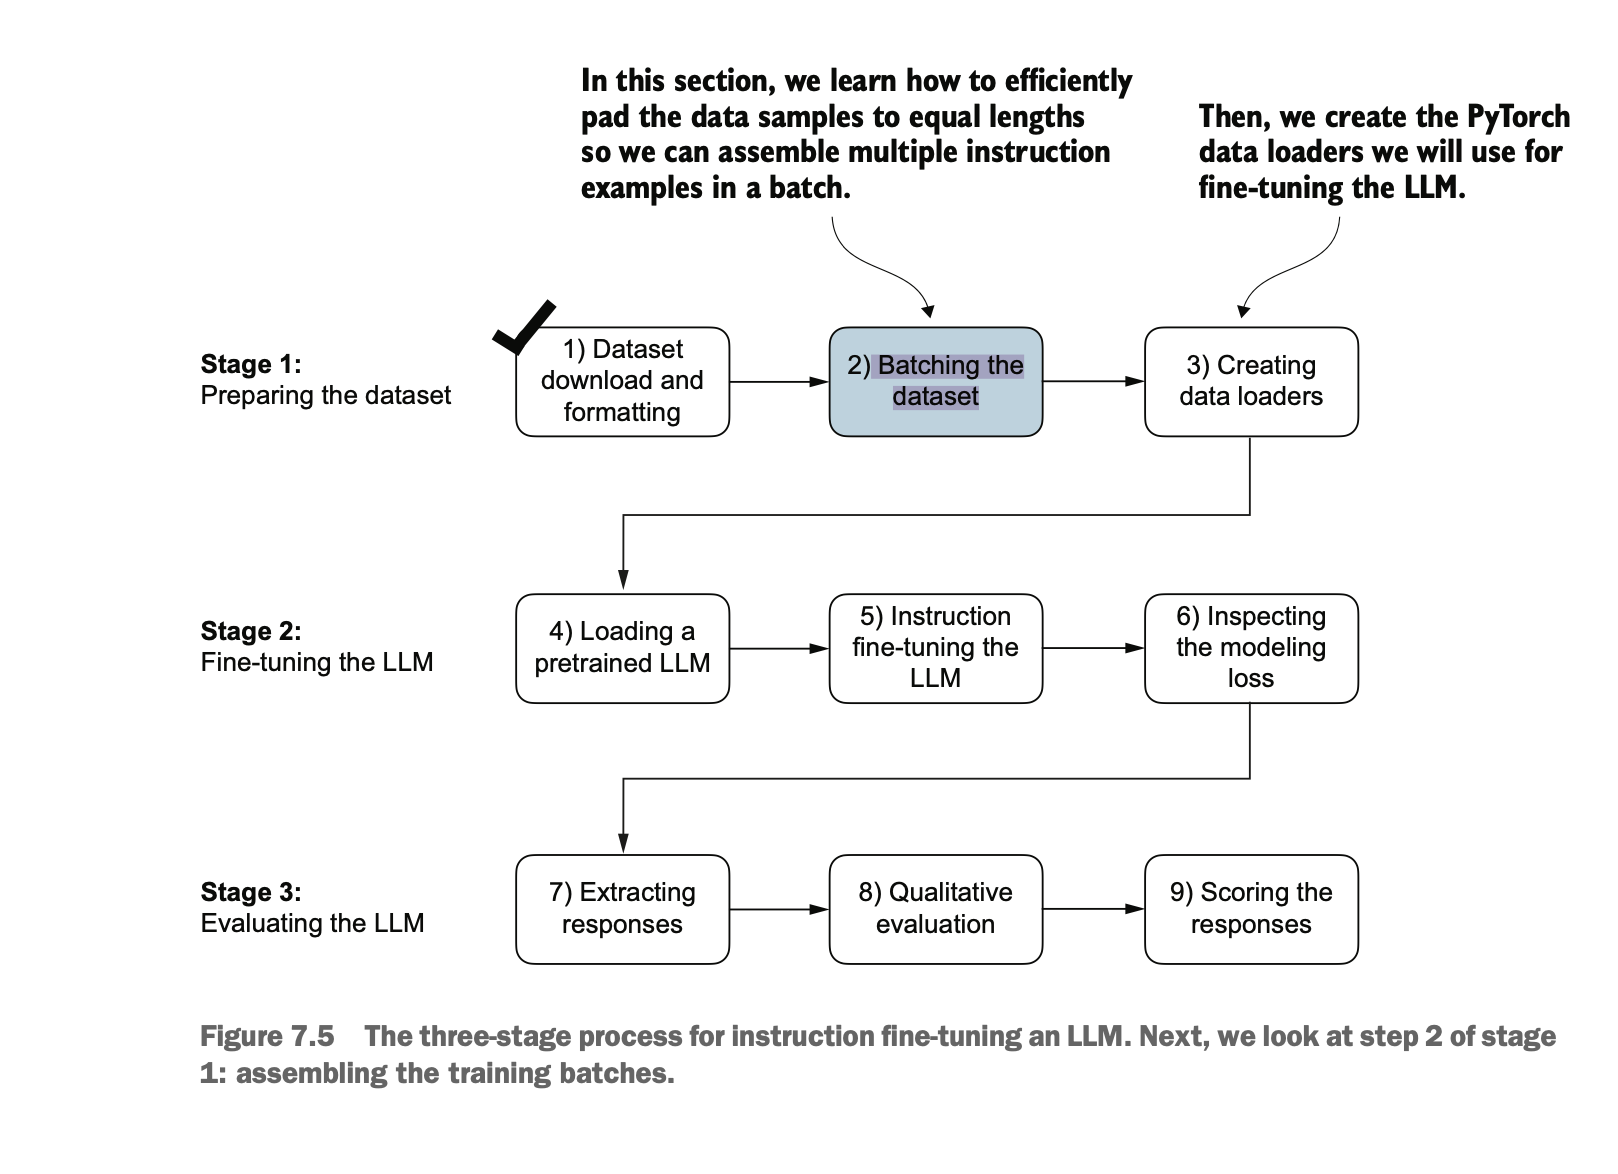

In normal PyTorch training, the DataLoader automatically batches data using a default collate function. But for instruction
fine-tuning, this default method is not enough.

So we need to create a custom collate function to handle the special formatting of our instruction dataset.
Steps involved:

Create an InstructionDataset class to format and tokenize all inputs

Build a custom collate function to merge samples into proper batches

Plug this custom function into the DataLoader

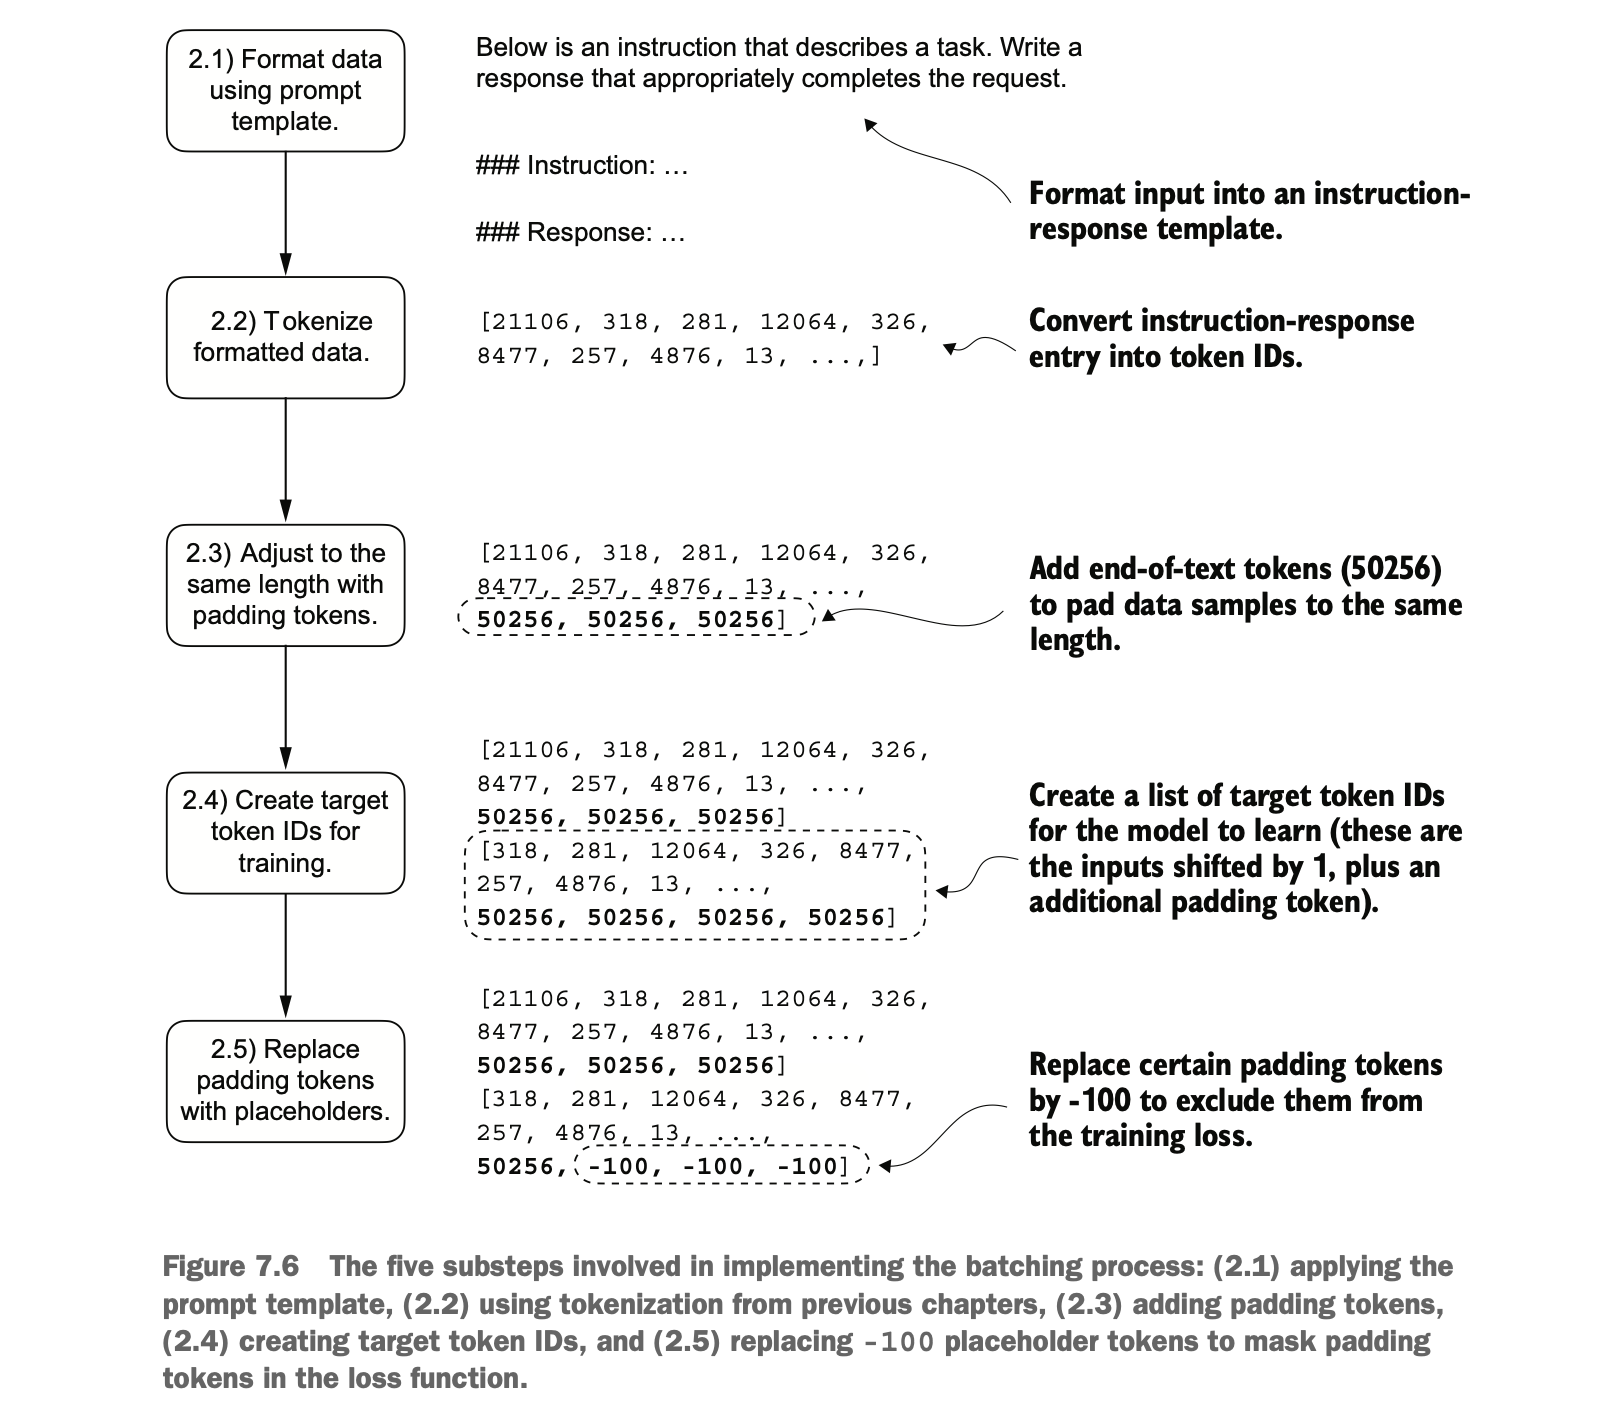

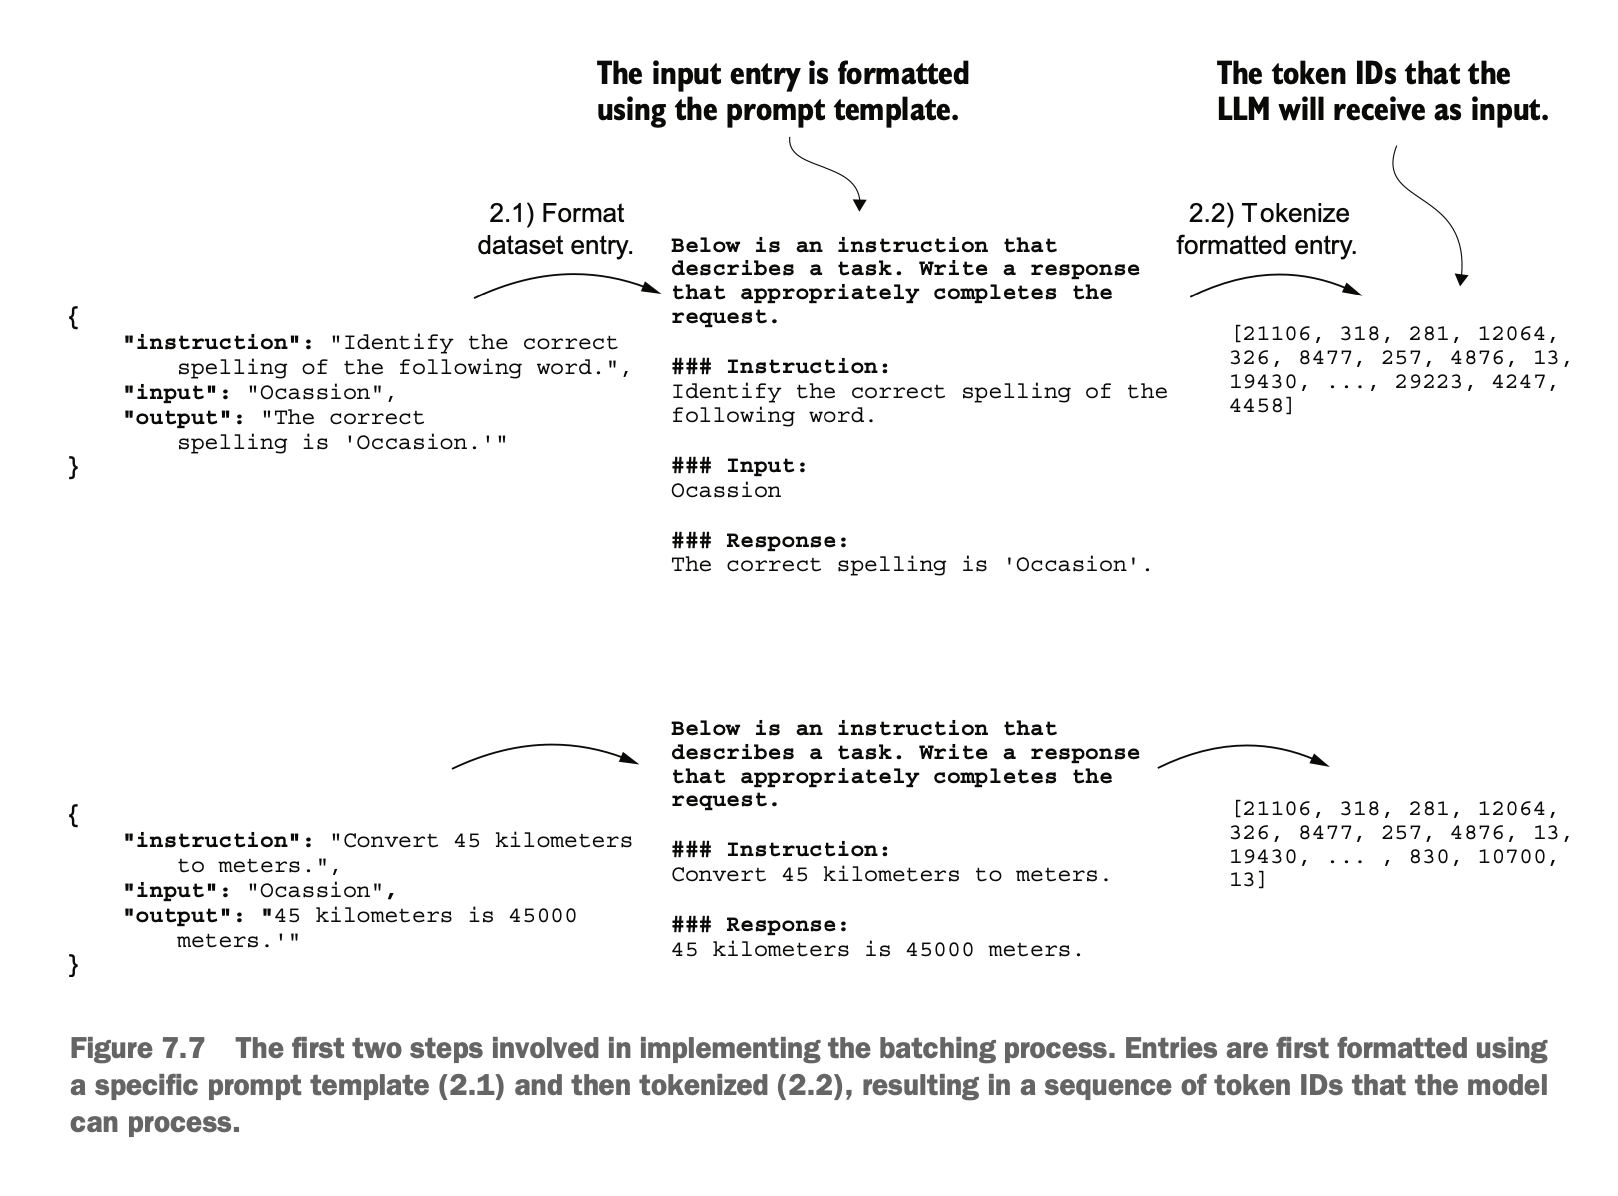

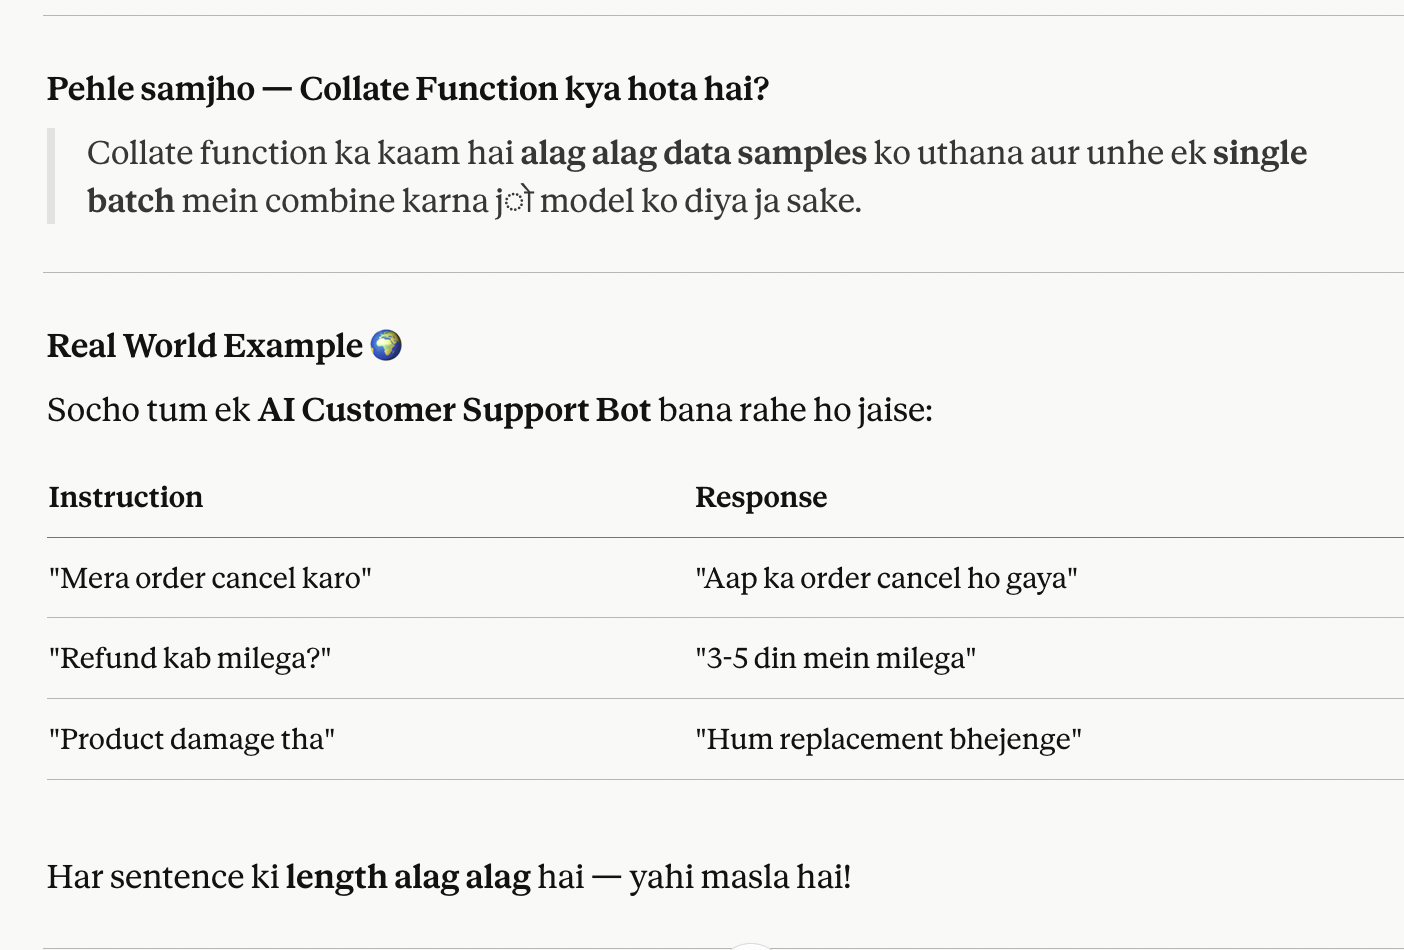

In [9]:
# Implementing an instruction dataset class

import torch # ya aik pythone lubrary hai jis man ai k tool pry hwy hn
from torch.utils.data import Dataset
# torch.utils.data -> torch k under aik diba hai us ka name utils hai us k under aik or folder  hai jis ka name folder hai
# Yeh class ek dataset banata hai jo language model ko fine-tune karne ke liye use hota hai. Matlab model ko sikhana hai ke "agar koi instruction de, to uska sahi response kaise dena hai."
# dataset mean 3 kam perform krta hai 1-> data ko call kerta hai jo actual mnn dataa hai 2, getitem function ko call kerta hai 3 data ki len ko find kerta hai

In [11]:
class instruction_dataset(Dataset):
   # -> hum yahan class bana rhy hn jo pytorch m dataset ki class ko use kerna hai dataset hummy 3 function provide kerta hai
  def __init__(self , data , tokenizer):
    self.data = data
    self. tokenizer_text = []
    for entry in data:
      instruction_and_input_call =input(entry)
      desire_output_call = f"\n\n### Response:\n{entry['output']}"
      full_text = instruction_and_input_call + desire_output_call
      self.tokenizer_text.append(

          tokenizer.encode(full_text)

          #tokenizer.encode(full_text) ka kaam kya hai?
#Aap ne likha "words convert in to number" — yeh baat thodi si galat hai. Sahi baat yeh hai:
#Tokenizer text ko tokens mein torta hai, aur har token ka ek number hota hai. Token zaroori nahi ke poora word ho — yeh word ka hissa bhi ho sakta hai.
#Misaal ke taur par GPT-2 tokenizer mein:
          #"Below" → [21106] (ek word, ek number)
#"tokenizer" → [30001, 7509] (ek word, lekin do tukre: "token" + "izer")
#"unbelievable" → teen tukron mein toot sakta hai: "un" + "believ" + "able"



          )


  def __getitem__(self , index):
    return self.tokenizer_text[index]
  def __len__(self):
    return len(self.data)






In [12]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))



[50256]
